# Projet de Prediction de Prix Immobiliers | Python, Linear Regression, Decision Tree, Random Forest, Scikit-learn


L'objectif de ce projet est de construire un modèle de machine learning capable de prédire le prix médian des logements (`median_house_value`) dans un bloc résidentiel en Californie, à partir de caractéristiques géographiques, démographiques et socio-économiques.


## Auteur
* **Nom :** Abdoulaye DABO
* **Filière :** Élève Ingénieur en Intelligence Artificielle & Big Data (ESP)
* **Contact :** [abdoulayedabo@esp.sn](mailto:abdoulayedabo@esp.sn)

---


## Description du dataset

Le dataset issue utlise dans ce projet est issue de Kaggle: https://www.kaggle.com/datasets/shibumohapatra/house-price



Le dataset contient **9 variables explicatives** :
- **Localisation** : `longitude`, `latitude`
- **Caractéristiques du logement** : `housing_median_age`, `total_rooms`, `total_bedrooms`
- **Population et ménages** : `population`, `households`
- **Revenu** : `median_income`
- **Proximité à l'océan** : `ocean_proximity` (variable catégorielle)

La variable cible est `median_house_value`.

Ce projet couvrira les étapes classiques d'un pipeline de data science : exploration et visualisation des données (EDA), traitement des valeurs manquantes, encodage des variables catégorielles, feature engineering, entraînement de plusieurs modèles de régression (Régression Linéaire, Random Forest, XGBoost, etc.), évaluation des performances (RMSE, MAE, R²) et interprétation des résultats.


## Importation des biblioteques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sc
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## Chargement du dataset

In [2]:
housing_data = pd.read_csv('/content/housing.csv')
print(housing_data.shape, "\n")
print(housing_data.info(), "\n")
print(housing_data.head(), "\n")
print(housing_data.dtypes, "\n")

(20640, 10) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB
None 

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.

⚠️
Ces informations nous montrent qu'il y des valeurs nulles dans la colonne total_bedrooms.

## EDA

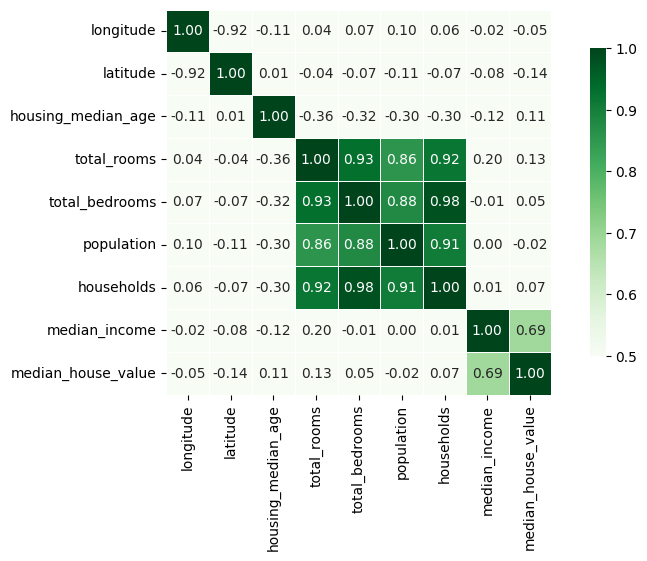

In [3]:
corr = housing_data.corr(numeric_only=True)
plt.figure(figsize=(10,5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0.5,
    vmax=1.0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.show()

La heatmap de corrélation permet de visualiser la force des relations linéaires entre variables. On observe que les 6 paires de variables les plus corrélées sont : ménages/chambres totales (0,98), chambres totales/pièces totales (0,93), ménages/pièces totales (0,92), ménages/population (0,91), population/chambres totales (0,88), et population/pièces totales (0,86).

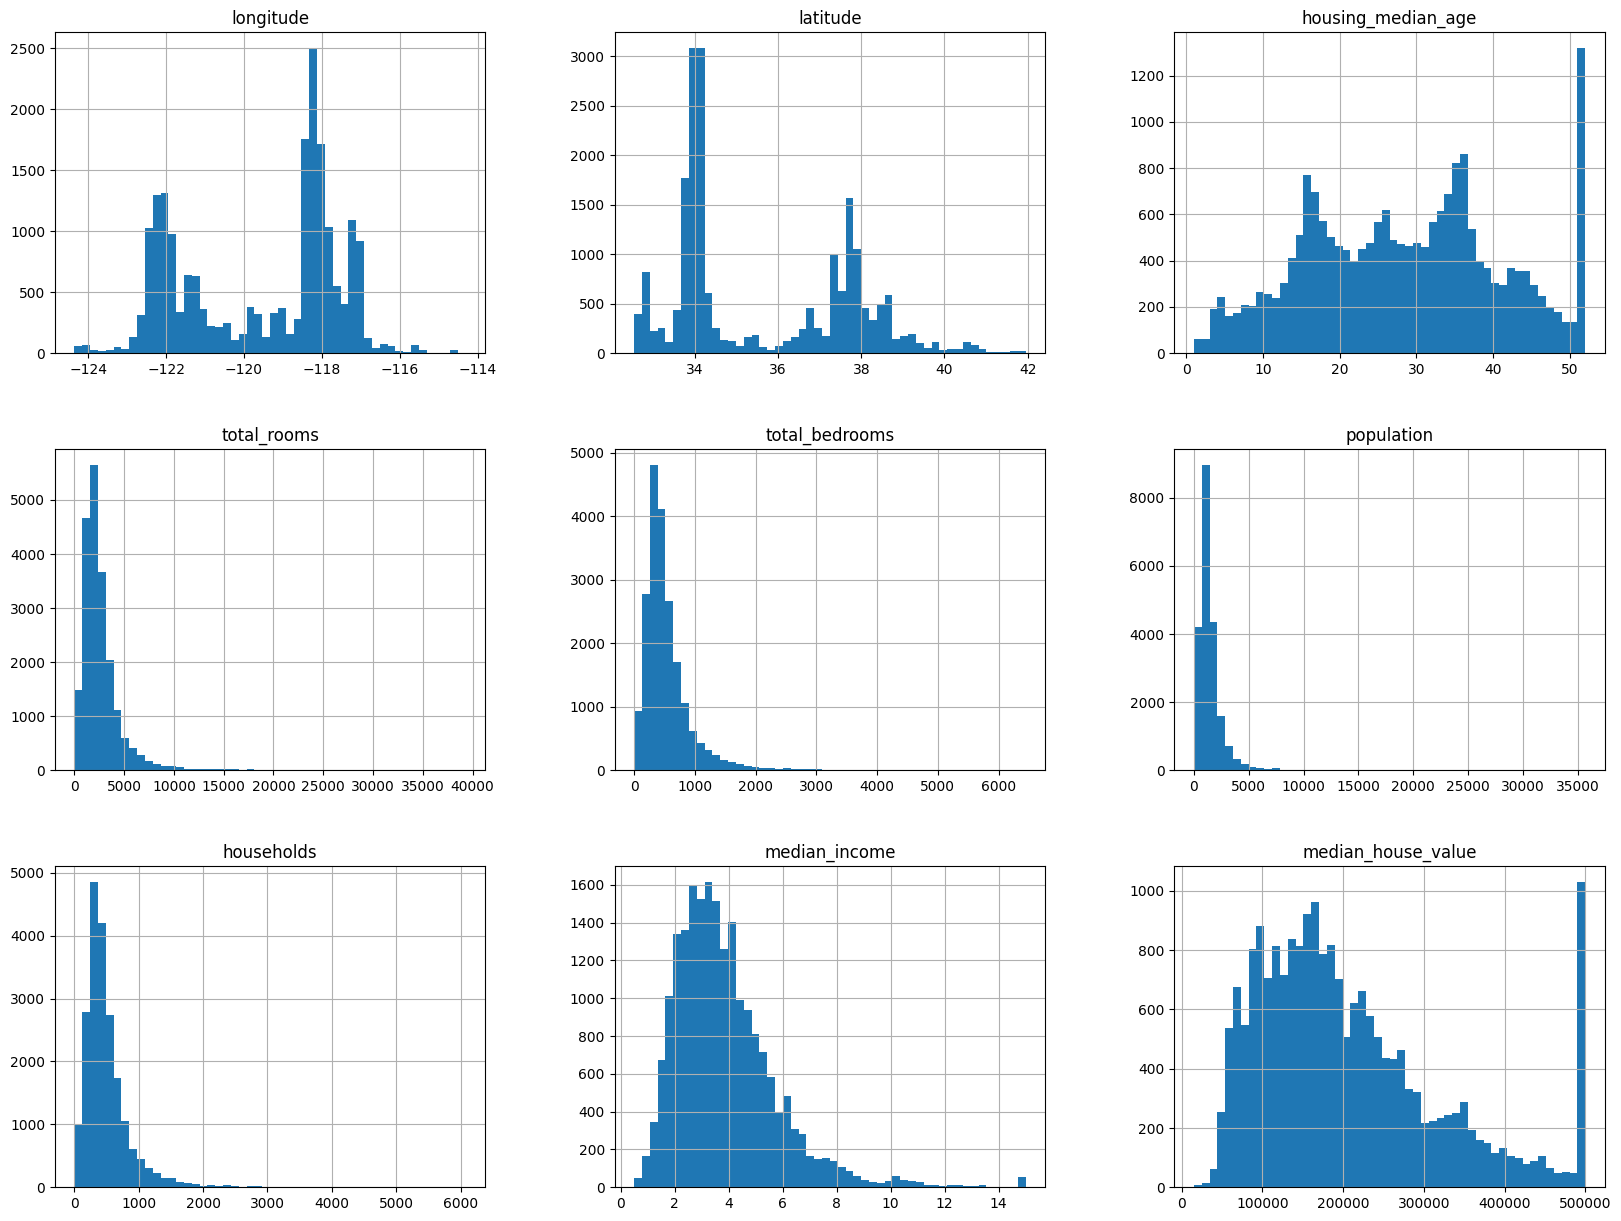

In [4]:
housing_data.hist(bins=50, figsize=(20,15))
plt.show()


On peut remarquer certaines colonnes ( L'âge médian du logement, le revenu médian et la valeur médiane de la maison ) ont été plafonnés. Ce dernier peut être un problème sérieux puisqu'il s'agit de votre attribut cible (vos étiquettes). Vos algorithmes d’apprentissage automatique peuvent apprendre que les prix ne dépassent jamais cette limite.

<Axes: xlabel='median_house_value', ylabel='Density'>

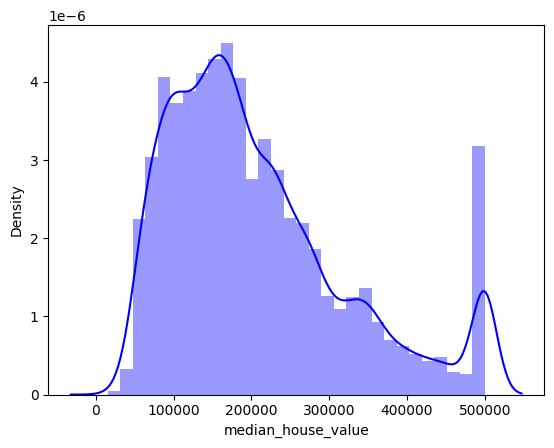

In [5]:
sns.distplot(
    housing_data['median_house_value'],
    bins=30,
    kde=True,
    color='blue'
)

**Distribution principale**
- La majorité des maisons se situe entre 100 000 \$ et 300 000 \$
- Le pic (mode) est autour de 180 000 $

**Outliers visibles**
- Le pic anormal à 500 000 $ → valeurs plafonnées artificiellement (capped)

**Distribution asymétrique (skewed right)**
- La queue à droite est longue → quelques maisons très chères tirent la moyenne vers le haut

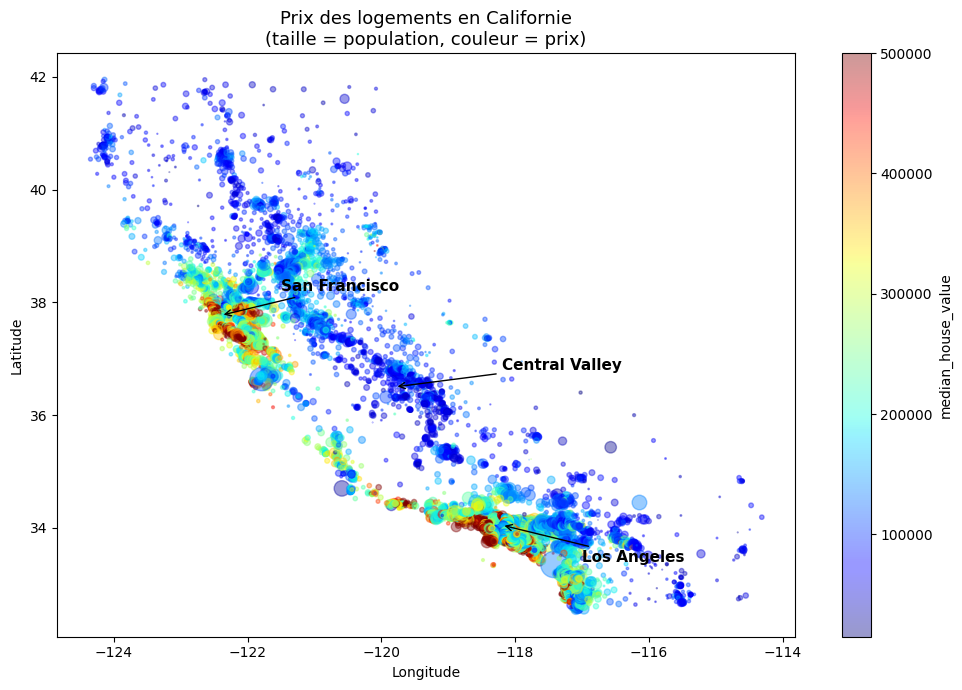

In [6]:
import matplotlib.pyplot as plt
import numpy as np

housing_data.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=housing_data["population"] / 100,
    c="median_house_value",
    cmap=plt.get_cmap("jet"),
    colorbar=True,
    figsize=(10, 7)
)

plt.annotate("San Francisco", xy=(-122.4, 37.77), fontsize=11,
             color="black", fontweight="bold",
             xytext=(-121.5, 38.2),
             arrowprops=dict(arrowstyle="->", color="black"))

plt.annotate("Los Angeles", xy=(-118.2, 34.05), fontsize=11,
             color="black", fontweight="bold",
             xytext=(-117.0, 33.4),
             arrowprops=dict(arrowstyle="->", color="black"))

plt.annotate("Central Valley", xy=(-119.8, 36.5), fontsize=11,
             color="black", fontweight="bold",
             xytext=(-118.2, 36.8),
             arrowprops=dict(arrowstyle="->", color="black"))

plt.title("Prix des logements en Californie\n(taille = population, couleur = prix)", fontsize=13)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig("housing_map.png", dpi=150)
plt.show()

- **Plus tu es proche de la côte** → plus les prix sont élevés
- **Plus la densité de population est forte** → plus les prix montent
- Les 3 zones les plus denses et chères sont **San Francisco**, **Los Angeles** et la **vallée centrale (Central Valley)**


## Preparation des donnees

### Gestion des outliers

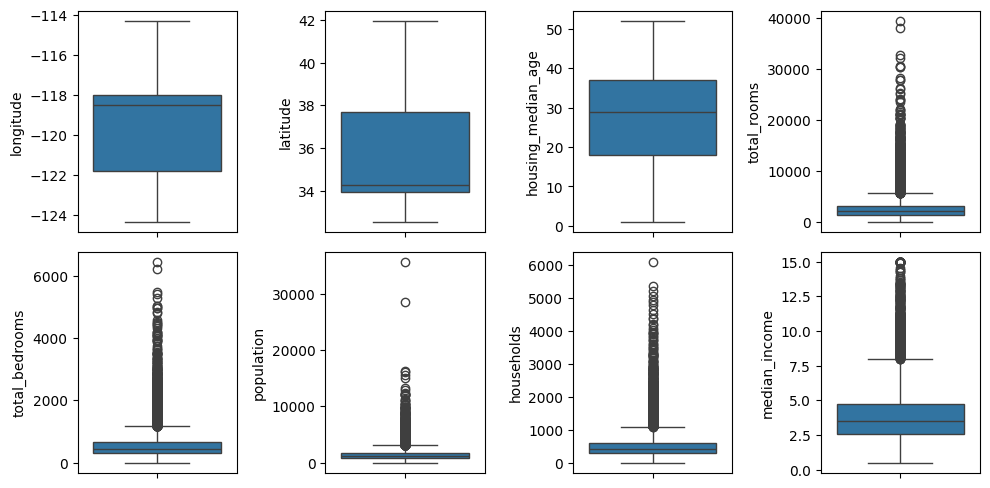

In [7]:
numericall_columns = housing_data.drop('median_house_value', axis = 1).select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(10,5))
for i, col in enumerate(numericall_columns):
    plt.subplot(2, 4, i+1)
    sns.boxplot(housing_data[col])
plt.tight_layout()
plt.show()

In [8]:
Q1 = housing_data[numericall_columns].quantile(0.25)
Q3 = housing_data[numericall_columns].quantile(0.75)

IQR = Q3 - Q1
# print(IQR)

lower_bound = Q1-1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

def cap_outliers(df, lower_bound, upper_bound, cols):
    df_copy = df.copy()
    if cols is None:
        cols = df.columns
    df_copy[numericall_columns] = df_copy[cols].apply(lambda x: np.where(x < lower_bound[x.name], lower_bound[x.name], x))
    df_copy[numericall_columns] = df_copy[cols].apply(lambda x: np.where(x > upper_bound[x.name], upper_bound[x.name], x))
    return df_copy

housing_data = cap_outliers(housing_data, lower_bound, upper_bound, numericall_columns)



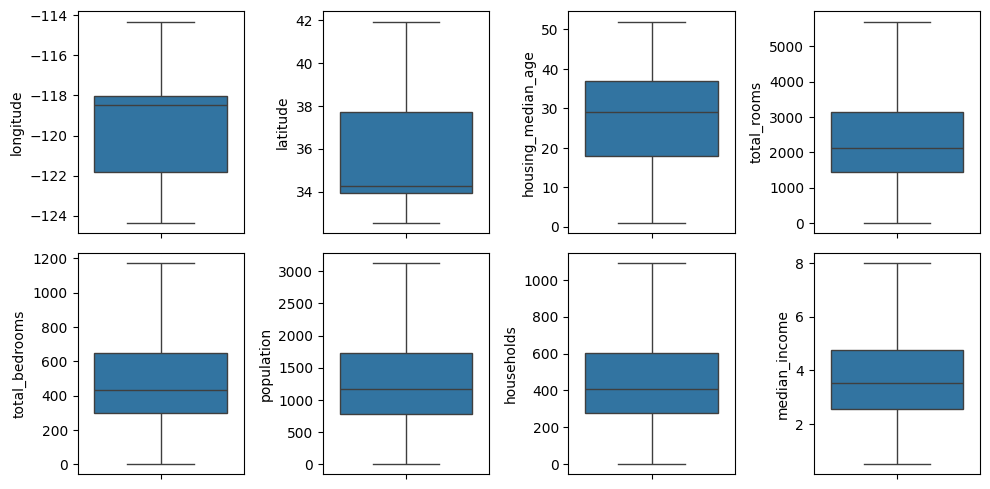

In [9]:
plt.figure(figsize=(10,5))
for i, col in enumerate(numericall_columns):
    plt.subplot(2, 4, i+1)
    sns.boxplot(housing_data[col])
plt.tight_layout()
plt.show()

Nous pouvons remarquer que les outliers ont ete suprimes.

### Gestion des données manquantes

In [10]:
housing_data_copy = housing_data.copy(deep=True)
total_bedrooms_mean = housing_data['total_bedrooms'].mean()
housing_data_copy.fillna(total_bedrooms_mean, inplace=True)
housing_data_copy.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
ocean_proximity,0
median_house_value,0


### Ecodage des variables catégrorielles

In [11]:
# ocean_proximity_dummy = pd.get_dummies(housing_data_copy["ocean_proximity"])
# # print(ocean_proximity_dummy.head())
# housing_data_encoded = pd.concat([housing_data_copy, ocean_proximity_dummy], axis=1)
# housing_data_encoded.drop("ocean_proximity", axis=1, inplace=True)
# housing_data_encoded.head()

ohe = OneHotEncoder(handle_unknown="ignore")
ohe.fit(housing_data_copy[["ocean_proximity"]])
# print(ohe.categories_)
ocean_proximity_ohe = ohe.transform(housing_data_copy[["ocean_proximity"]]).toarray()
ocean_proximity_ohe = pd.DataFrame(ocean_proximity_ohe, columns=ohe.categories_[0])
housing_data_encoded = pd.concat([housing_data_copy, ocean_proximity_ohe], axis=1)
housing_data_encoded.drop("ocean_proximity", axis=1, inplace=True)
housing_data_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.013025,452600,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,5698.375,1106.0,2401.0,1092.5,8.013025,358500,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.257400,352100,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.643100,341300,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.846200,342200,0.0,0.0,0.0,1.0,0.0


### Scaling

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>,
        <Axes: title={'center': 'total_rooms'}>],
       [<Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>,
        <Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>],
       [<Axes: title={'center': 'median_house_value'}>,
        <Axes: title={'center': '<1H OCEAN'}>,
        <Axes: title={'center': 'INLAND'}>,
        <Axes: title={'center': 'ISLAND'}>],
       [<Axes: title={'center': 'NEAR BAY'}>,
        <Axes: title={'center': 'NEAR OCEAN'}>, <Axes: >, <Axes: >]],
      dtype=object)

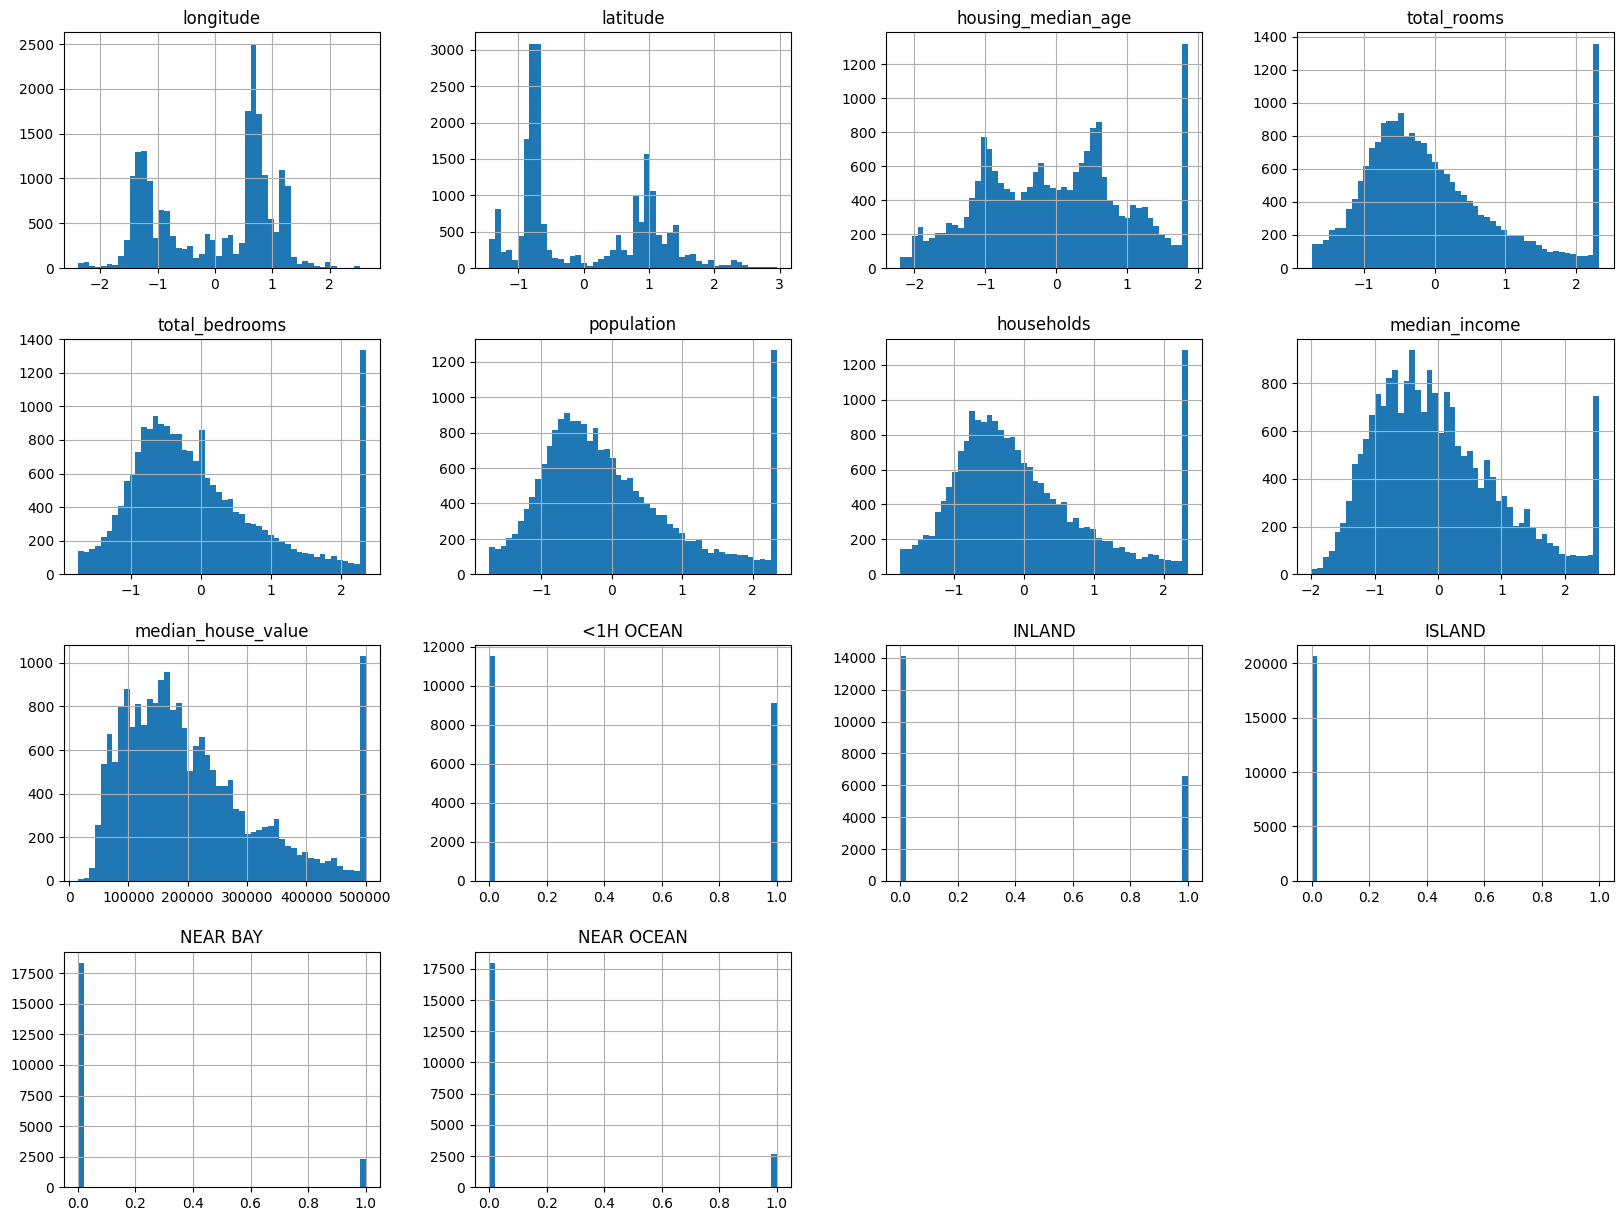

In [32]:
housing_data_scaled = housing_data_encoded.copy()
housing_data_scaled[numericall_columns] = (housing_data_scaled[numericall_columns] - housing_data_scaled[numericall_columns].mean()) / housing_data_scaled[numericall_columns].std()
housing_data_scaled.hist(bins=50, figsize=(20,15))

## Modelisation

In [34]:
housing_data_scaled["income_cat"] = pd.cut(
    housing_data_scaled["median_income"],
    bins=[-np.inf, 0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5, 6]
)


# print(housing_data_scaled["income_cat"].value_counts() / len(housing_data_scaled))

train_set, test_set = train_test_split(
    housing_data_scaled,
    test_size=0.2,
    random_state=42,
    stratify=housing_data_scaled["income_cat"]
)

# print(train_set["income_cat"].value_counts() / len(train_set))
# print(test_set["income_cat"].value_counts() / len(test_set))

for set_ in (train_set, test_set):
    set_.drop("income_cat", axis=1, inplace=True)

housing_data_scaled = housing_data_scaled.drop("income_cat", axis=1)

X_train = train_set.drop("median_house_value", axis=1)
y_train = train_set["median_house_value"]
X_test = test_set.drop("median_house_value", axis=1)
y_test = test_set["median_house_value"]


### Regression lineaire

In [35]:
reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("R2 :", r2_score(y_test, y_pred))

RMSE : 66276.76527240295
MAE : 49799.895809520895
R2 : 0.6771787559744507


### Decision Tree

In [23]:
dt = DecisionTreeRegressor(random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, None],
    'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['squared_error', 'absolute_error', 'poisson']
}

random_search = RandomizedSearchCV(estimator=dt, param_distributions=param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
random_search.fit(X_train, y_train)
# print("Best parameters:", random_search.best_params_)
# print("Best score:", random_search.best_score_)

dt = DecisionTreeRegressor(random_state=42, **random_search.best_params_)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("R2 :", r2_score(y_test, y_pred))

RMSE : 67641.06524650083
MAE : 45494.63699127907
R2 : 0.6489479783907974


### Random forest

In [24]:
rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("R2 :", r2_score(y_test, y_pred))

RMSE : 47816.91250532761
MAE : 31312.961661821708
R2 : 0.8245660415607007


## Sources

* https://medium.com/jungletronics/pandas-one-hot-encoding-ohe-eb7467dc92e8

* https://apxml.com/courses/intermediate-python-programming-ml/chapter-3-data-manipulation-pandas/pandas-missing-data

* https://www.kaggle.com/code/marcinrutecki/one-hot-encoding-everything-you-need-to-know

* https://www.kaggle.com/code/yunasheng/identifying-and-handling-outliers-in-pandas


